In [4]:
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA_CORE_AMD_32/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")

13 Dateien gefunden.
Daten erfolgreich zusammengeführt.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a3_o80_m10_an10_ar9_reduced,PSA,269.29,0.418079,0.939152,0.585257,0.136978,21.052632,0.186180,0.496814
1,a3_o80_m10_an10_ar9_reduced,DBSA,56.93,0.771186,0.167454,0.545460,0.254846,51.127820,0.043510,0.554835
2,a3_o80_m10_an10_ar9_reduced,TPSA,80.08,0.717514,0.175951,0.514057,0.205167,27.819549,0.058923,0.665767
3,a5_o96_m10_an10_ar10_reduced,PSA,207.00,0.452381,0.829761,0.292725,0.247295,13.705584,0.123441,0.405650
4,a5_o96_m10_an10_ar10_reduced,DBSA,43.25,0.751323,0.208839,0.225052,0.299698,54.822335,0.059679,0.651439


Durchschnittswerte berechnet.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a10_o107_m5_an57_ar12,DBSA,40.528333,0.711750,0.188482,0.267092,0.272815,42.700852,0.040179,0.501261
1,a10_o107_m5_an57_ar12,PSA,167.019167,0.440166,0.764825,0.242286,0.209551,18.121889,0.047032,0.449324
2,a10_o107_m5_an57_ar12,TPSA,47.174167,0.728253,0.153310,0.233336,0.206074,39.177258,0.041019,0.694788
3,a10_o114_m6_an57_ar11,DBSA,55.935000,0.763957,0.163149,0.274166,0.172998,46.125377,0.067624,0.817257
4,a10_o114_m6_an57_ar11,PSA,314.351667,0.468807,0.750197,0.343675,0.130588,19.688426,0.118702,0.813794


Aggregierte Datei gespeichert unter: /Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA_CORE_AMD_32/Metrics_averaged.csv


In [5]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DBSA,40.528,0.712,0.188,0.267,0.273,42.701,0.040,0.501
a10_o107_m5_an57_ar12,PSA,167.019,0.440,0.765,0.242,0.210,18.122,0.047,0.449
a10_o107_m5_an57_ar12,TPSA,47.174,0.728,0.153,0.233,0.206,39.177,0.041,0.695
a10_o114_m6_an57_ar11,DBSA,55.935,0.764,0.163,0.274,0.173,46.125,0.068,0.817
a10_o114_m6_an57_ar11,PSA,314.352,0.469,0.750,0.344,0.131,19.688,0.119,0.814
a10_o114_m6_an57_ar11,TPSA,67.582,0.721,0.147,0.259,0.171,34.186,0.067,0.939
a10_o128_m6_an51_ar13,DBSA,50.600,0.758,0.237,0.004,0.257,43.912,0.048,0.814
a10_o128_m6_an51_ar13,PSA,221.522,0.387,0.590,0.004,0.254,16.861,0.094,0.855
a10_o128_m6_an51_ar13,TPSA,61.970,0.786,0.204,0.004,0.177,39.227,0.051,0.956
a10_o144_m6_an53_ar12,DBSA,38.113,0.564,0.155,0.399,0.337,31.960,0.057,0.568


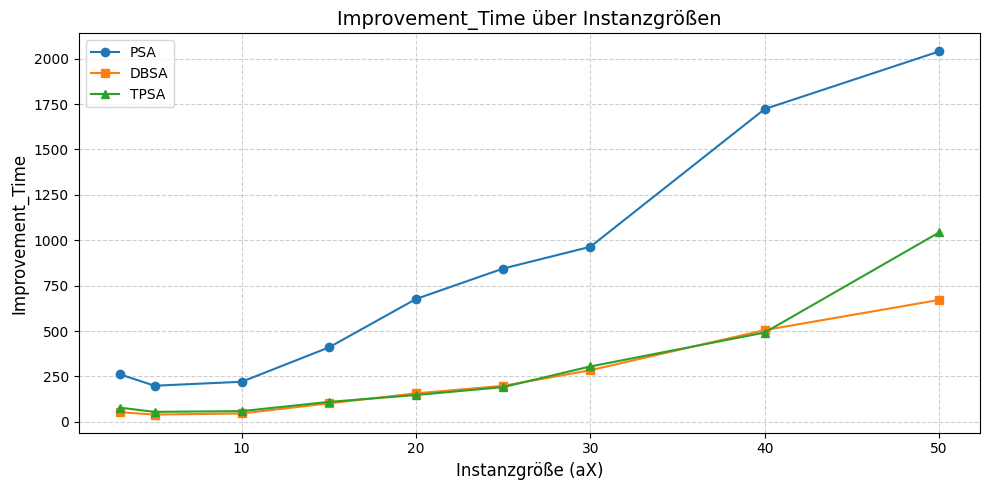

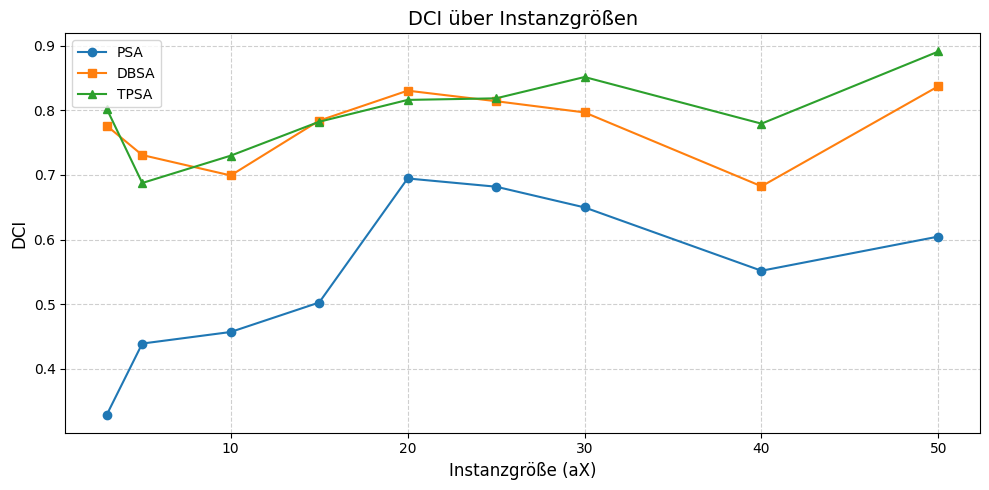

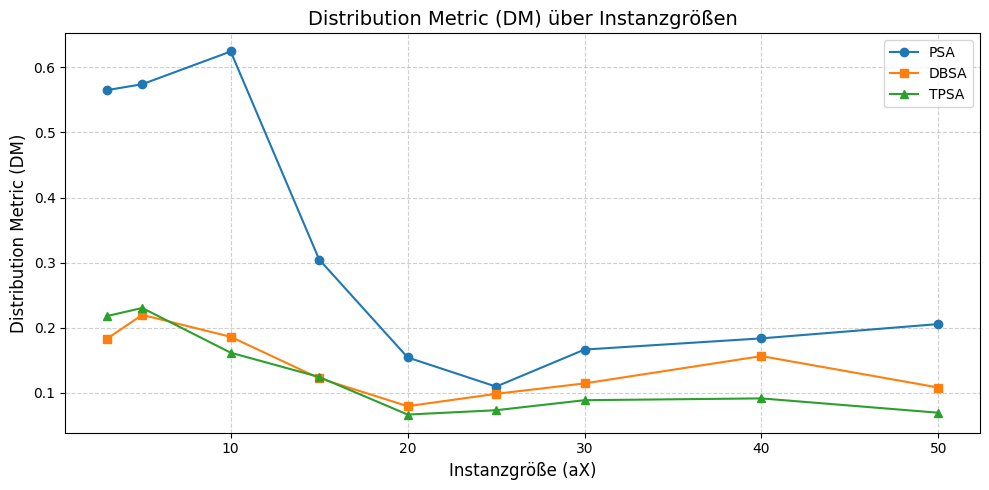

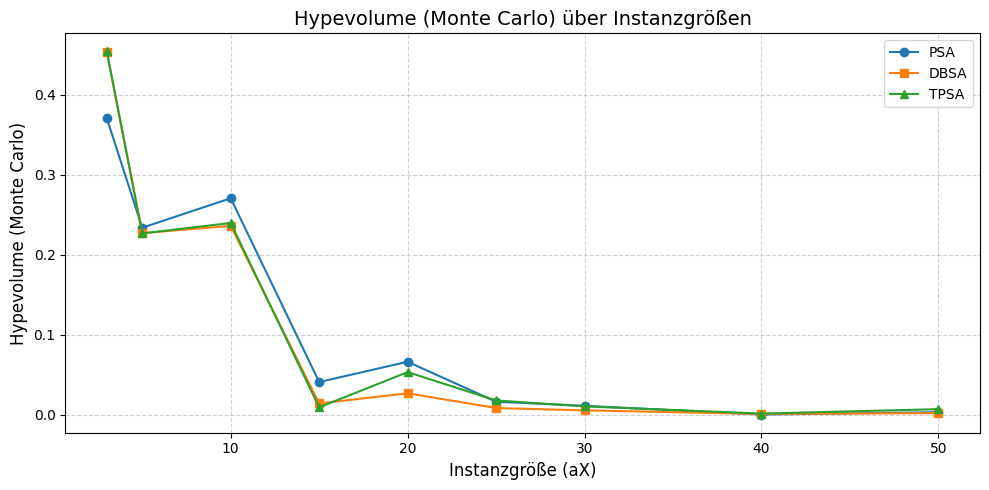

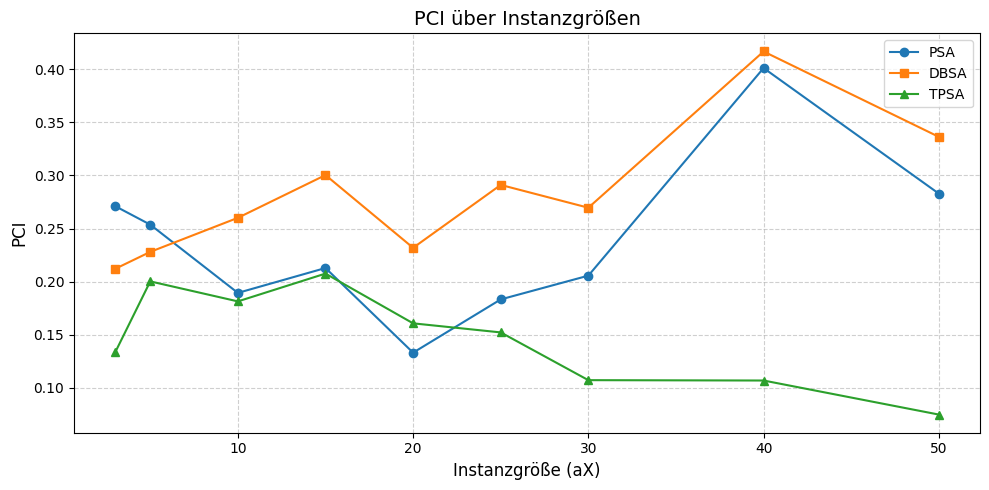

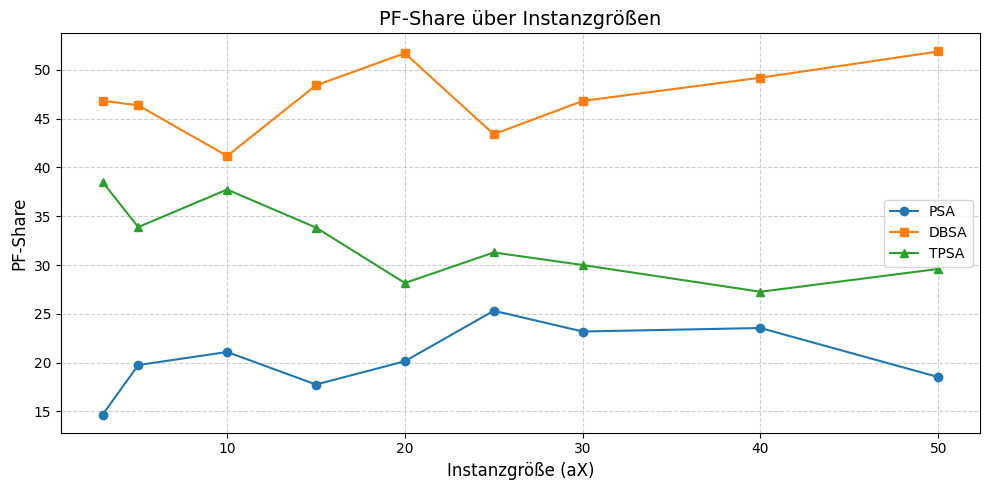

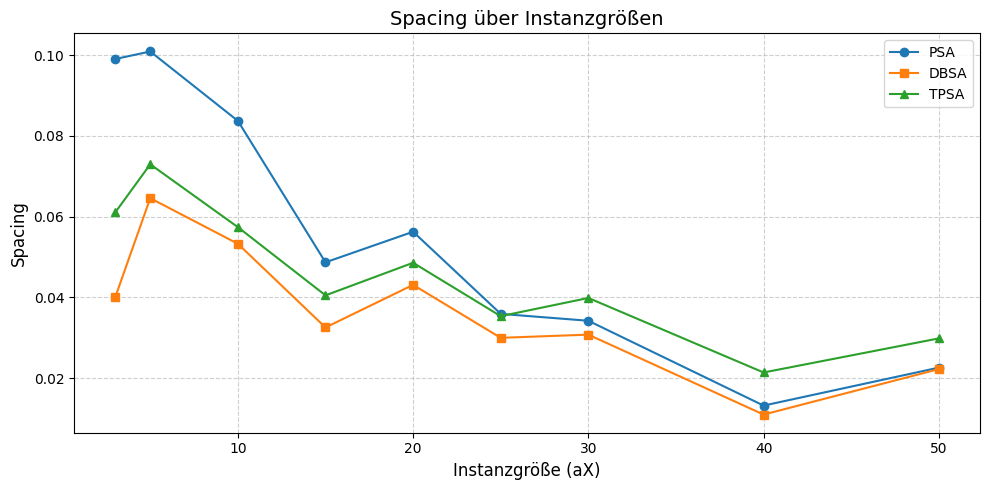

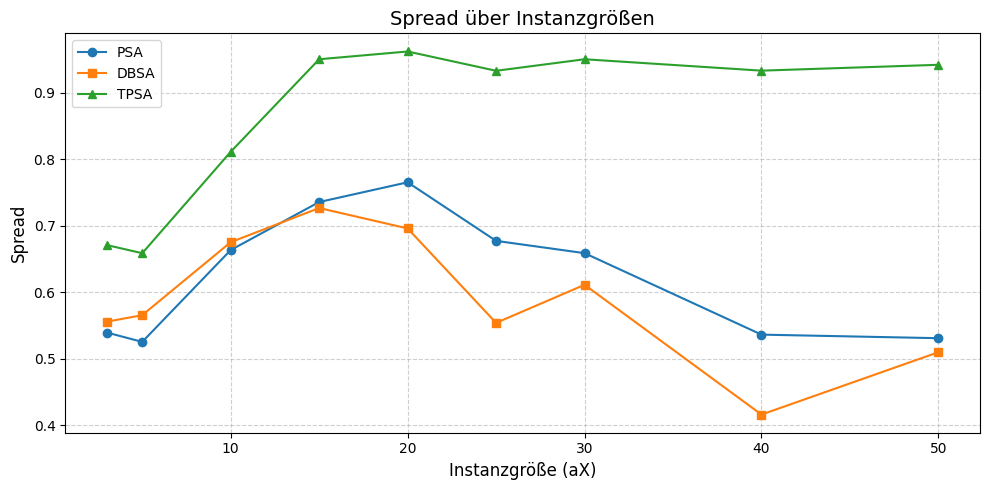

In [6]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Datei einlesen
file_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solutions_TPSA_CORE_AMD_32/Metrics_averaged.csv"
df = pd.read_csv(file_path)

# 🔍 Instanzgröße extrahieren (z. B. 'a3_o80' → 3)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🧹 Metriken auswählen (alle außer 'Instance', 'Algorithm', 'Instance_Size')
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Mittelwert pro (Instance_Size, Algorithm)
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()

# 📊 Sortieren nach Instanzgröße
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Visualisierung: Jede Metrik als eigenes Diagramm
for metric in metrics:
    plt.figure(figsize=(10, 5))

    # PSA-Linie
    psa_data = agg_df[agg_df["Algorithm"] == "PSA"]
    plt.plot(psa_data["Instance_Size"], psa_data[metric], marker="o", label="PSA")

    # DBSA-Linie
    dbsa_data = agg_df[agg_df["Algorithm"] == "DBSA"]
    plt.plot(dbsa_data["Instance_Size"], dbsa_data[metric], marker="s", label="DBSA")

    # TPSA-Linie
    tpsa_data = agg_df[agg_df["Algorithm"] == "TPSA"]
    plt.plot(tpsa_data["Instance_Size"], tpsa_data[metric], marker="^", label="TPSA")

    # ✨ Formatierung
    plt.title(f"{metric} über Instanzgrößen", fontsize=14)
    plt.xlabel("Instanzgröße (aX)", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,183.058,0.754,0.152,0.140,0.277,45.771,0.041,0.611,19.0
PSA,666.664,0.523,0.397,0.152,0.225,20.608,0.062,0.635,19.0
TPSA,221.536,0.779,0.134,0.145,0.156,33.621,0.048,0.854,19.0


In [8]:
# Standardabweichungen je Algorithmus
df.groupby("Algorithm").std(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,207.207,0.076,0.049,0.172,0.066,5.248,0.017,0.126,14.623
PSA,630.641,0.117,0.242,0.176,0.075,4.154,0.035,0.133,14.623
TPSA,290.300,0.064,0.059,0.177,0.043,4.407,0.017,0.137,14.623
